In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import seaborn as sns

In [2]:
file = "/home/zhe2/data/PACE/adding_sif_output/PACE_OCI.20260125T163441.L1B.V3_adding_sif_zero_subregion_lbfgsb_20260408.nc"
ds = xr.open_dataset(file)
# ds = ds.isel(scans=slice(0, 200), pixels=slice(800, 1100))
ds

<xarray.Dataset> Size: 45MB
Dimensions:             (scans: 200, pixels: 301, state: 15, sif_nev: 1,
                         red_wavelength: 83)
Coordinates:
  * red_wavelength      (red_wavelength) float32 332B 642.0 642.7 ... 754.2
Dimensions without coordinates: scans, pixels, state, sif_nev
Data variables:
    latitude            (scans, pixels) float32 241kB ...
    longitude           (scans, pixels) float32 241kB ...
    x_hat               (state, scans, pixels) float32 4MB ...
    converged           (scans, pixels) uint8 60kB ...
    sif_ev1             (scans, pixels) float32 241kB ...
    sif_coeffs          (sif_nev, scans, pixels) float32 241kB ...
    sif_radiance_678nm  (scans, pixels) float32 241kB ...
    sif_added_678nm     (scans, pixels) float32 241kB ...
    rmse                (red_wavelength, scans, pixels) float32 20MB ...
    Rtoa_red            (red_wavelength, scans, pixels) float32 20MB ...
Attributes:
    title:            PACE AddingSIF retrieval output (spectrally resolved rmse)
    history:          Created 2026-04-09T09:29:56
    input_pace_file:  /home/zhe2/data/PACE/adding_sif_interim/interim_2026012...
    config_file:      /home/zhe2/data/PACE/adding_sif_interim/merged_config_a...
    state_names_csv:  vcd_o2_intercept,vcd_o2_slope,vcd_h2o_intercept,vcd_h2o...
    pixel_start:      800
    pixel_end:        1100
    scan_start:       1
    scan_end:         200

In [3]:
# wavelength
wavelength = ds["red_wavelength"]
# rmse
rmse = ds["rmse"]
# converged
converged = ds["converged"]
# select ONLY the converged pixels
rmse_conv = np.where(converged==1, rmse, np.nan)
# squeeze the first two dimensions
rmse_flat = rmse.values.reshape(rmse_conv.shape[0], rmse_conv.shape[1]*rmse_conv.shape[2])
rmse_conv_flat = rmse_conv.reshape(rmse_conv.shape[0], rmse_conv.shape[1]*rmse_conv.shape[2])
print(np.nansum(rmse_conv_flat==rmse_conv_flat))
print(np.nansum(rmse_flat==rmse_flat))

515596
4649245


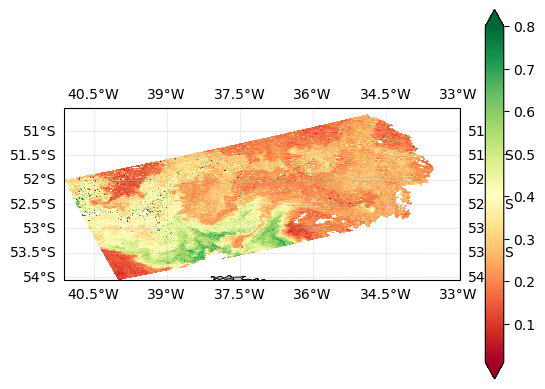

In [4]:
lat = ds["latitude"]
lon = ds["longitude"]
converged = ds["converged"]
sif_radiance_678nm = ds["sif_radiance_678nm"]
sif_radiance_678nm_conv = np.where(converged==1, sif_radiance_678nm, np.nan)

# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

# Set global extent
buffer_bnd = .25
lon_min = np.min(lon) - buffer_bnd
lon_max = np.max(lon) + buffer_bnd
lat_min = np.min(lat) - buffer_bnd
lat_max = np.max(lat) + buffer_bnd
extend = [lon_min, lon_max, lat_min, lat_max]
# ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon, lat, sif_radiance_678nm, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = .01,
                 vmax = .8,
                #  levels=np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

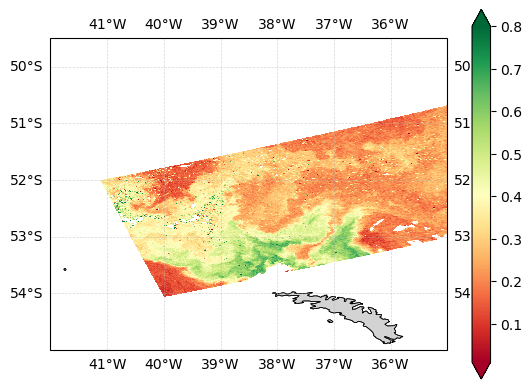

In [5]:
lat = ds["latitude"]
lon = ds["longitude"]
converged = ds["converged"]
sif_radiance_678nm = ds["sif_radiance_678nm"]
sif_radiance_678nm_conv = np.where(converged==1, sif_radiance_678nm, np.nan)

# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

extent1 = [-42, -35, -55, -49.5]
# [2, 8, 61.5, 67.5]
ax.set_extent(extent1, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon, lat, sif_radiance_678nm, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = .01,
                 vmax = .8,
                #  levels=np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

In [6]:
rmse_conv_flat

array([[        nan,  0.04515574,         nan, ...,         nan,
                nan,         nan],
       [        nan,  0.00680125,         nan, ...,         nan,
                nan,         nan],
       [        nan, -0.00758313,         nan, ...,         nan,
                nan,         nan],
       ...,
       [        nan,  0.00328761,         nan, ...,         nan,
                nan,         nan],
       [        nan, -0.00135031,         nan, ...,         nan,
                nan,         nan],
       [        nan, -0.00335961,         nan, ...,         nan,
                nan,         nan]], shape=(83, 60200), dtype=float32)

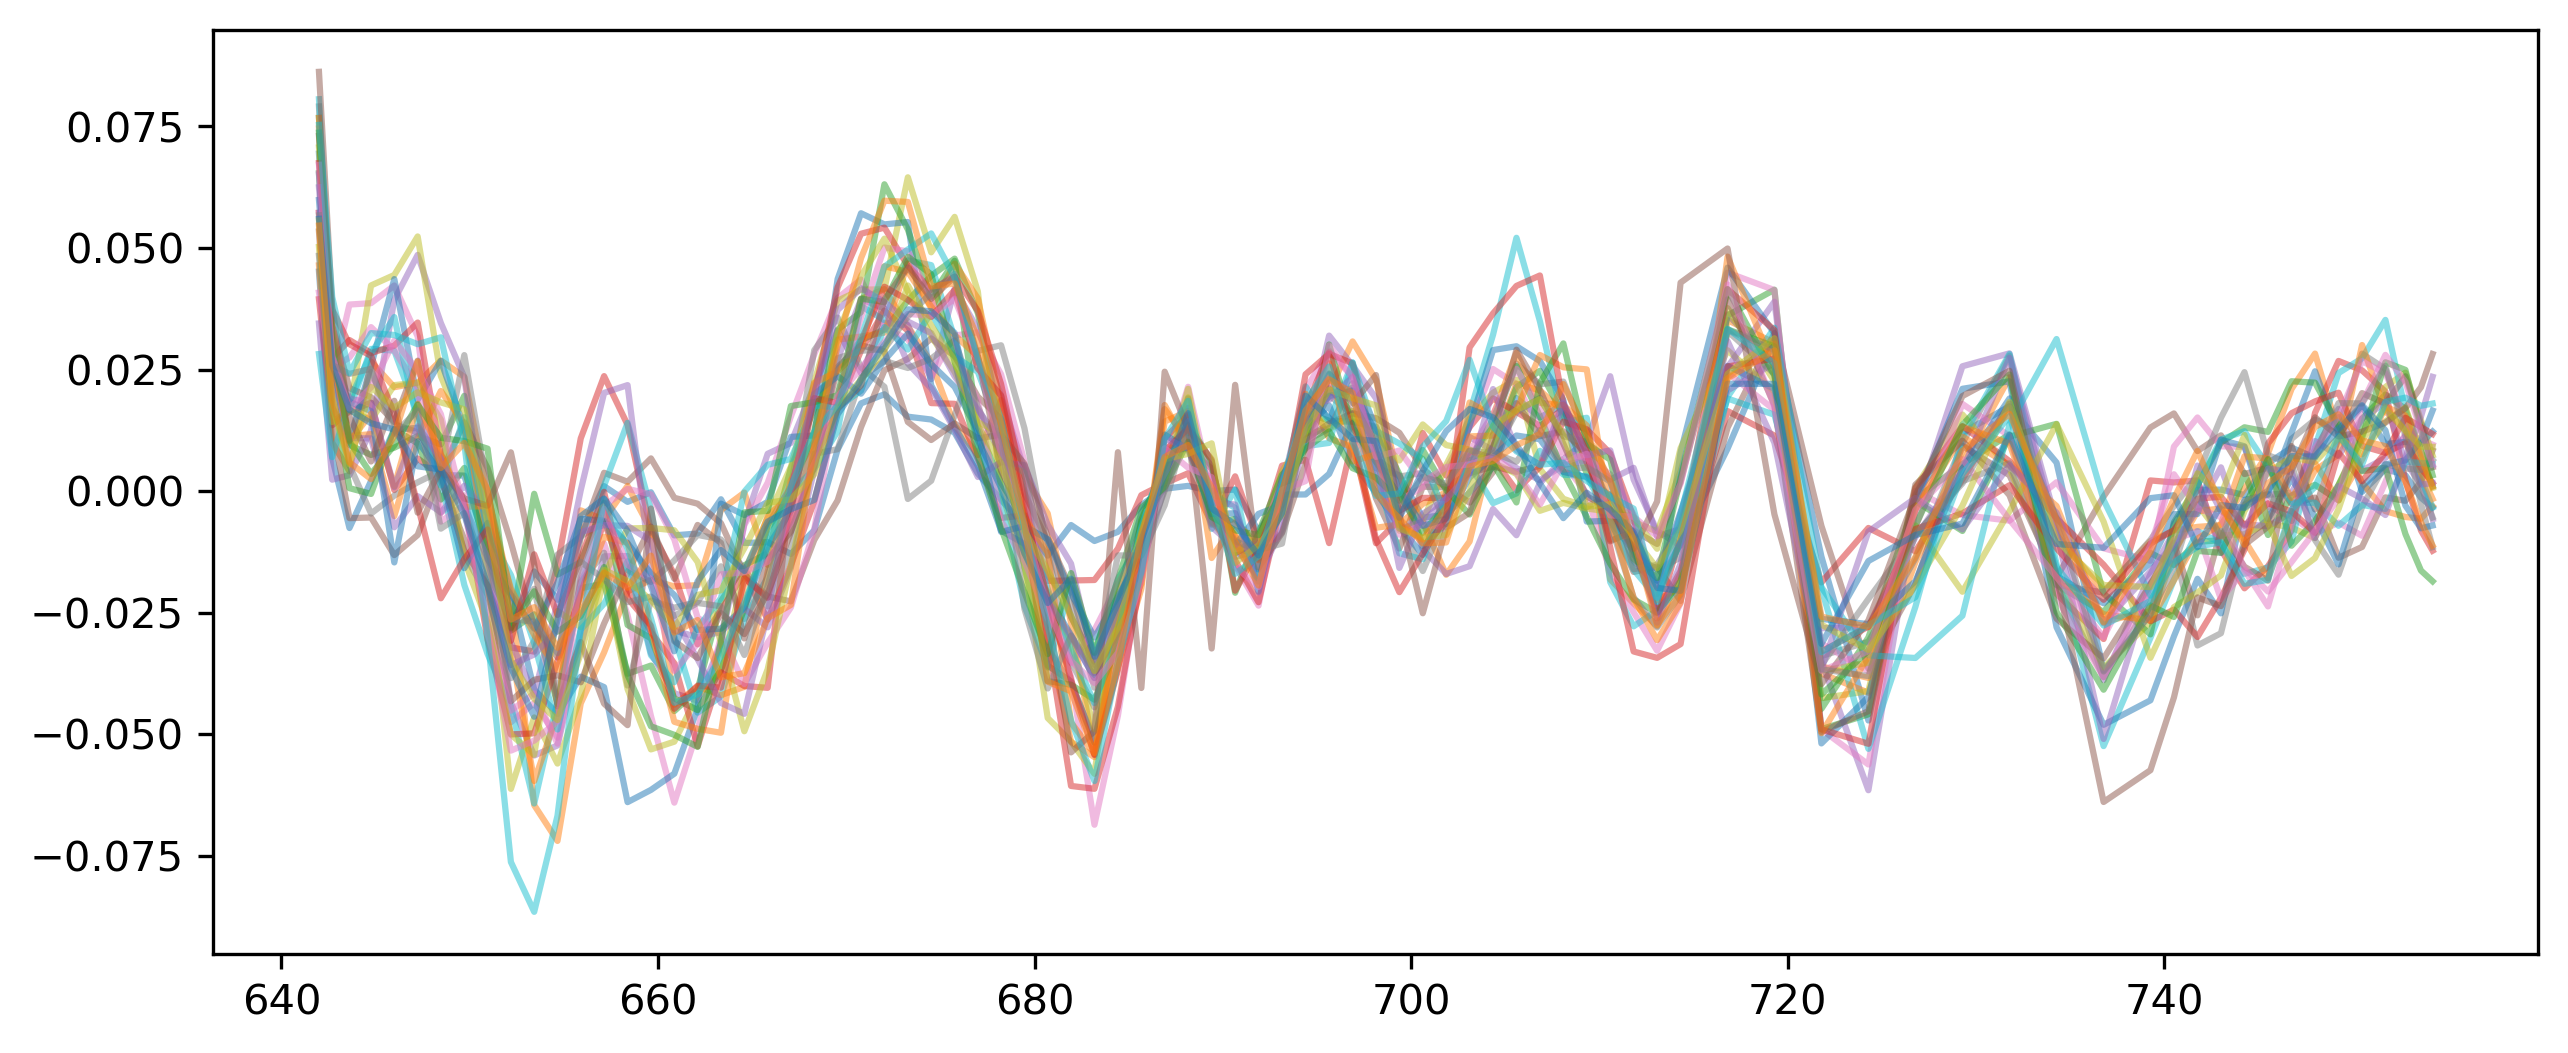

In [9]:
red_wavelength = ds["red_wavelength"]
# rmse_reshape = rmse.values.reshape(rmse.shape[0], rmse.shape[1]*rmse.shape[2])
idx = np.where(rmse_conv_flat[0,:]>=-np.inf)[0]

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.plot(red_wavelength, rmse_conv_flat[:,idx[::200]], alpha=.5)

In [8]:
# load L2 AOP and BGC data - nflh and chlor_a
granule_id = '20260125T163441'
dir_aop = "/home/zhe2/data/PACE/L2_AOP_V3.1/"
dir_bgc = "/home/zhe2/data/PACE/L2_BGC_V3.1/"
file_aop = dir_aop + "PACE_OCI." + granule_id + ".L2.OC_AOP.V3_1.nc"
file_bgc = dir_bgc + "PACE_OCI." + granule_id + ".L2.OC_BGC.V3_1.nc"
dtr_aop = xr.open_datatree(file_aop)
ds_aop = xr.merge(dtr_aop.to_dict().values())
dtr_bgc = xr.open_datatree(file_bgc)
ds_bgc = xr.merge(dtr_bgc.to_dict().values())

# lat and lon
lat_l2 = ds_bgc['latitude'].values
lon_l2 = ds_bgc['longitude'].values
# chlor_a
chlor_a = ds_bgc['chlor_a'].values
# nflh
nflh = ds_aop['nflh'].values
# phytoplankton carbon
phyto_c = ds_bgc['carbon_phyto'].values
# poc
poc = ds_bgc['poc'].values

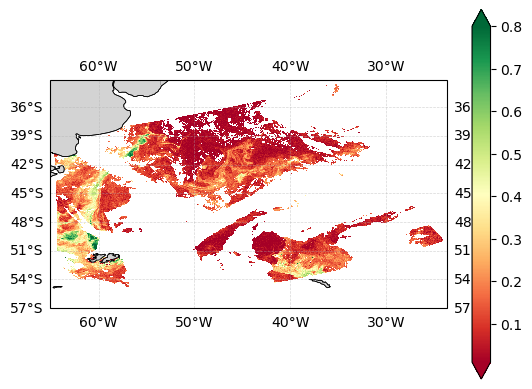

In [9]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon_l2, lat_l2, nflh, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.01,
                 vmax = 0.8,
                #  levels = np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

In [20]:
# read L1B data
file = "/home/zhe2/data/PACE/L1B_V3/PACE_OCI.20260125T163441.L1B.V3.nc"
dtr_l1b = xr.open_datatree(file)
ds_l1b = xr.merge(dtr_l1b.to_dict().values())
ds_l1b

<xarray.Dataset> Size: 5GB
Dimensions:                (blue_bands: 119, red_bands: 163, SWIR_bands: 9,
                            HAM_sides: 2, polarization_coefficients: 3,
                            scans: 1710, pixels: 1272, quaternion_elements: 4,
                            vector_elements: 3)
Coordinates:
    latitude               (scans, pixels) float32 9MB ...
    longitude              (scans, pixels) float32 9MB ...
Dimensions without coordinates: blue_bands, red_bands, SWIR_bands, HAM_sides,
                                polarization_coefficients, scans, pixels,
                                quaternion_elements, vector_elements
Data variables: (12/37)
    blue_wavelength        (blue_bands) float32 476B ...
    blue_solar_irradiance  (blue_bands) float32 476B ...
    red_wavelength         (red_bands) float32 652B ...
    red_solar_irradiance   (red_bands) float32 652B ...
    SWIR_wavelength        (SWIR_bands) float32 36B ...
    SWIR_bandpass          (SWIR_bands) float32 36B ...
    ...                     ...
    rhot_blue              (blue_bands, scans, pixels) float32 1GB ...
    rhot_red               (red_bands, scans, pixels) float32 1GB ...
    rhot_SWIR              (SWIR_bands, scans, pixels) float32 78MB ...
    qual_blue              (blue_bands, scans, pixels) float32 1GB ...
    qual_red               (red_bands, scans, pixels) float32 1GB ...
    qual_SWIR              (SWIR_bands, scans, pixels) float32 78MB ...
Attributes: (12/36)
    title:                             PACE OCI Level-1B Data
    instrument:                        OCI
    platform:                          PACE
    processing_level:                  L1B
    cdm_data_type:                     swath
    geospatial_lat_units:              degrees_north
    ...                                ...
    time_coverage_start:               2026-01-25T16:34:41.113Z
    time_coverage_end:                 2026-01-25T16:39:40.995Z
    processing_version:                3.0.1
    identifier_product_doi_authority:  https://dx.doi.org
    identifier_product_doi:            10.5067/PACE/OCI/L1B/SCI/3
    history:                           2026-02-25T04:44:45Z: l1bgen_oci ephfi...

#### <b>Discard below</b>

In [10]:
# check another batch retrieval file
file1 = "/home/zhe2/data/PACE/xSec_fit_output/interim_20250927T123954_retrieval_full_parallel.nc"
ds1 = xr.open_dataset(file1)
# loc
lat_ds1 = ds1['latitude'].values
lon_ds1 = ds1['longitude'].values
# sif 678 nm
sif_678_ds1 = ds1['sif_radiance_678nm'].values


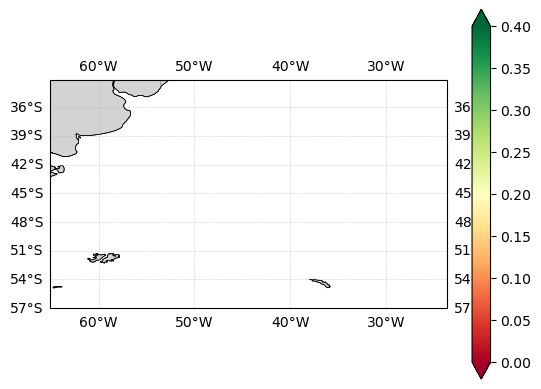

In [11]:
# mapping
fig = plt.figure()
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, alpha=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5, linestyle='--')

ax.set_extent(extend, crs=ccrs.PlateCarree()) 

# Plot nFLH data using contourf
im = ax.pcolormesh(lon_ds1, lat_ds1, sif_678_ds1, 
                 transform=ccrs.PlateCarree(),
                 cmap='RdYlGn',
                 vmin = 0.,
                 vmax = 0.4,
                #  levels = np.linspace(0, 1.4009, 20)
                 )
cbar = plt.colorbar(im, ax=ax, orientation='vertical', extend='both')

In [12]:
# subtract from my retrieval
delta_sif = sif_radiance_678nm - sif_678_ds1
# only convolved
delta_sif_conv = np.where(converged==1, delta_sif, np.nan)

(array([1.000e+00, 2.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 5.000e+00,
        5.000e+00, 1.400e+01, 1.200e+01, 1.500e+01, 2.000e+01, 2.500e+01,
        3.500e+01, 3.400e+01, 3.400e+01, 5.500e+01, 8.300e+01, 8.000e+01,
        1.260e+02, 1.690e+02, 2.550e+02, 3.700e+02, 5.080e+02, 5.770e+02,
        8.150e+02, 9.770e+02, 1.232e+03, 1.465e+03, 1.748e+03, 1.986e+03,
        2.266e+03, 2.384e+03, 2.550e+03, 2.553e+03, 2.422e+03, 2.244e+03,
        2.100e+03, 1.902e+03, 1.743e+03, 1.688e+03, 1.530e+03, 1.288e+03,
        1.061e+03, 8.370e+02, 7.200e+02, 6.040e+02, 4.590e+02, 4.400e+02,
        3.560e+02, 2.640e+02, 2.460e+02, 2.090e+02, 1.580e+02, 1.250e+02,
        1.130e+02, 8.200e+01, 6.500e+01, 5.900e+01, 5.300e+01, 4.000e+01,
        2.500e+01, 3.300e+01, 2.800e+01, 2.400e+01, 1.200e+01, 2.000e+01,
        1.500e+01, 1.200e+01, 1.500e+01, 1.200e+01, 1.000e+01, 1.000e+01,
        4.000e+00, 7.000e+00, 5.000e+00, 3.000e+00, 4.000e+00, 5.000e+00,
        3.000e+00, 4.000e+00, 0.000e+0

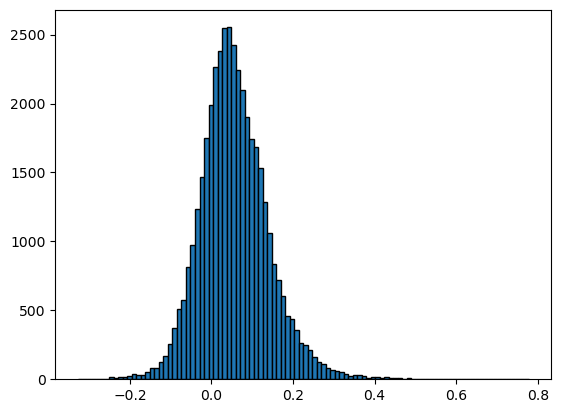

In [13]:
# histogram
plt.hist(delta_sif_conv.flatten(), bins=100, edgecolor='black')

(array([2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        1.0000e+00, 0.0000e+00, 3.0000e+00, 0.0000e+00, 2.0000e+00,
        1.0000e+00, 1.0000e+00, 2.0000e+00, 1.0000e+00, 1.0000e+00,
        2.0000e+00, 6.0000e+00, 1.1000e+01, 3.4000e+01, 7.2000e+01,
        1.5300e+02, 2.5500e+02, 3.8300e+02, 7.1500e+02, 1.4180e+03,
        2.8740e+03, 5.0970e+03, 8.3950e+03, 1.2022e+04, 1.4065e+04,
        1.3138e+04, 1.0065e+04, 8.2190e+03, 6.38

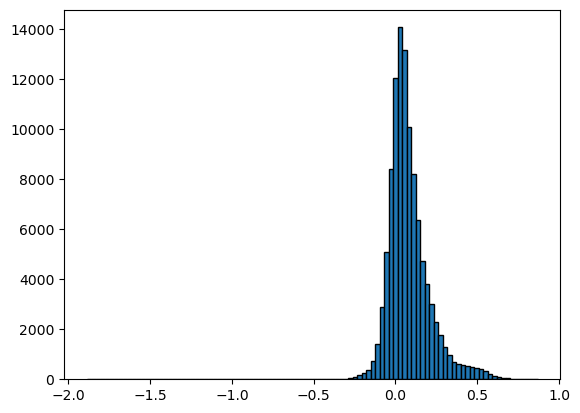

In [14]:
# all 
plt.hist(delta_sif.values.flatten(), bins=100, edgecolor='black')

### <b>Look into the residual</b>

In [15]:
# again, read l1b data

In [16]:
ds_bgc

<xarray.Dataset> Size: 70MB
Dimensions:           (number_of_bands: 286, number_of_reflective_bands: 286,
                       number_of_lines: 1710, pixels_per_line: 1272)
Dimensions without coordinates: number_of_bands, number_of_reflective_bands,
                                number_of_lines, pixels_per_line
Data variables: (12/31)
    wavelength        (number_of_bands) float64 2kB ...
    vcal_gain         (number_of_reflective_bands) float32 1kB ...
    vcal_offset       (number_of_reflective_bands) float32 1kB ...
    F0                (number_of_reflective_bands) float32 1kB ...
    aw                (number_of_reflective_bands) float32 1kB ...
    bbw               (number_of_reflective_bands) float32 1kB ...
    ...                ...
    chlor_a_unc       (number_of_lines, pixels_per_line) float32 9MB ...
    carbon_phyto_unc  (number_of_lines, pixels_per_line) float32 9MB ...
    l2_flags          (number_of_lines, pixels_per_line) int32 9MB ...
    longitude         (number_of_lines, pixels_per_line) float32 9MB -64.64 ....
    latitude          (number_of_lines, pixels_per_line) float32 9MB -56.78 ....
    tilt              (number_of_lines) float32 7kB ...
Attributes: (12/47)
    title:                             OCI Level-2 Data BGC
    product_name:                      PACE_OCI.20260125T163441.L2.OC_BGC.V3_...
    processing_version:                3.1
    history:                           l2gen par=/data3/sdpsoper/vdc/vpu26/wo...
    instrument:                        OCI
    platform:                          PACE
    ...                                ...
    geospatial_lon_min:                -64.776436
    startDirection:                    Ascending
    endDirection:                      Ascending
    day_night_flag:                    Day
    earth_sun_distance_correction:     1.031728982925415
    geospatial_bounds:                 POLYGON((-35.00380 -33.42133, -64.7764...

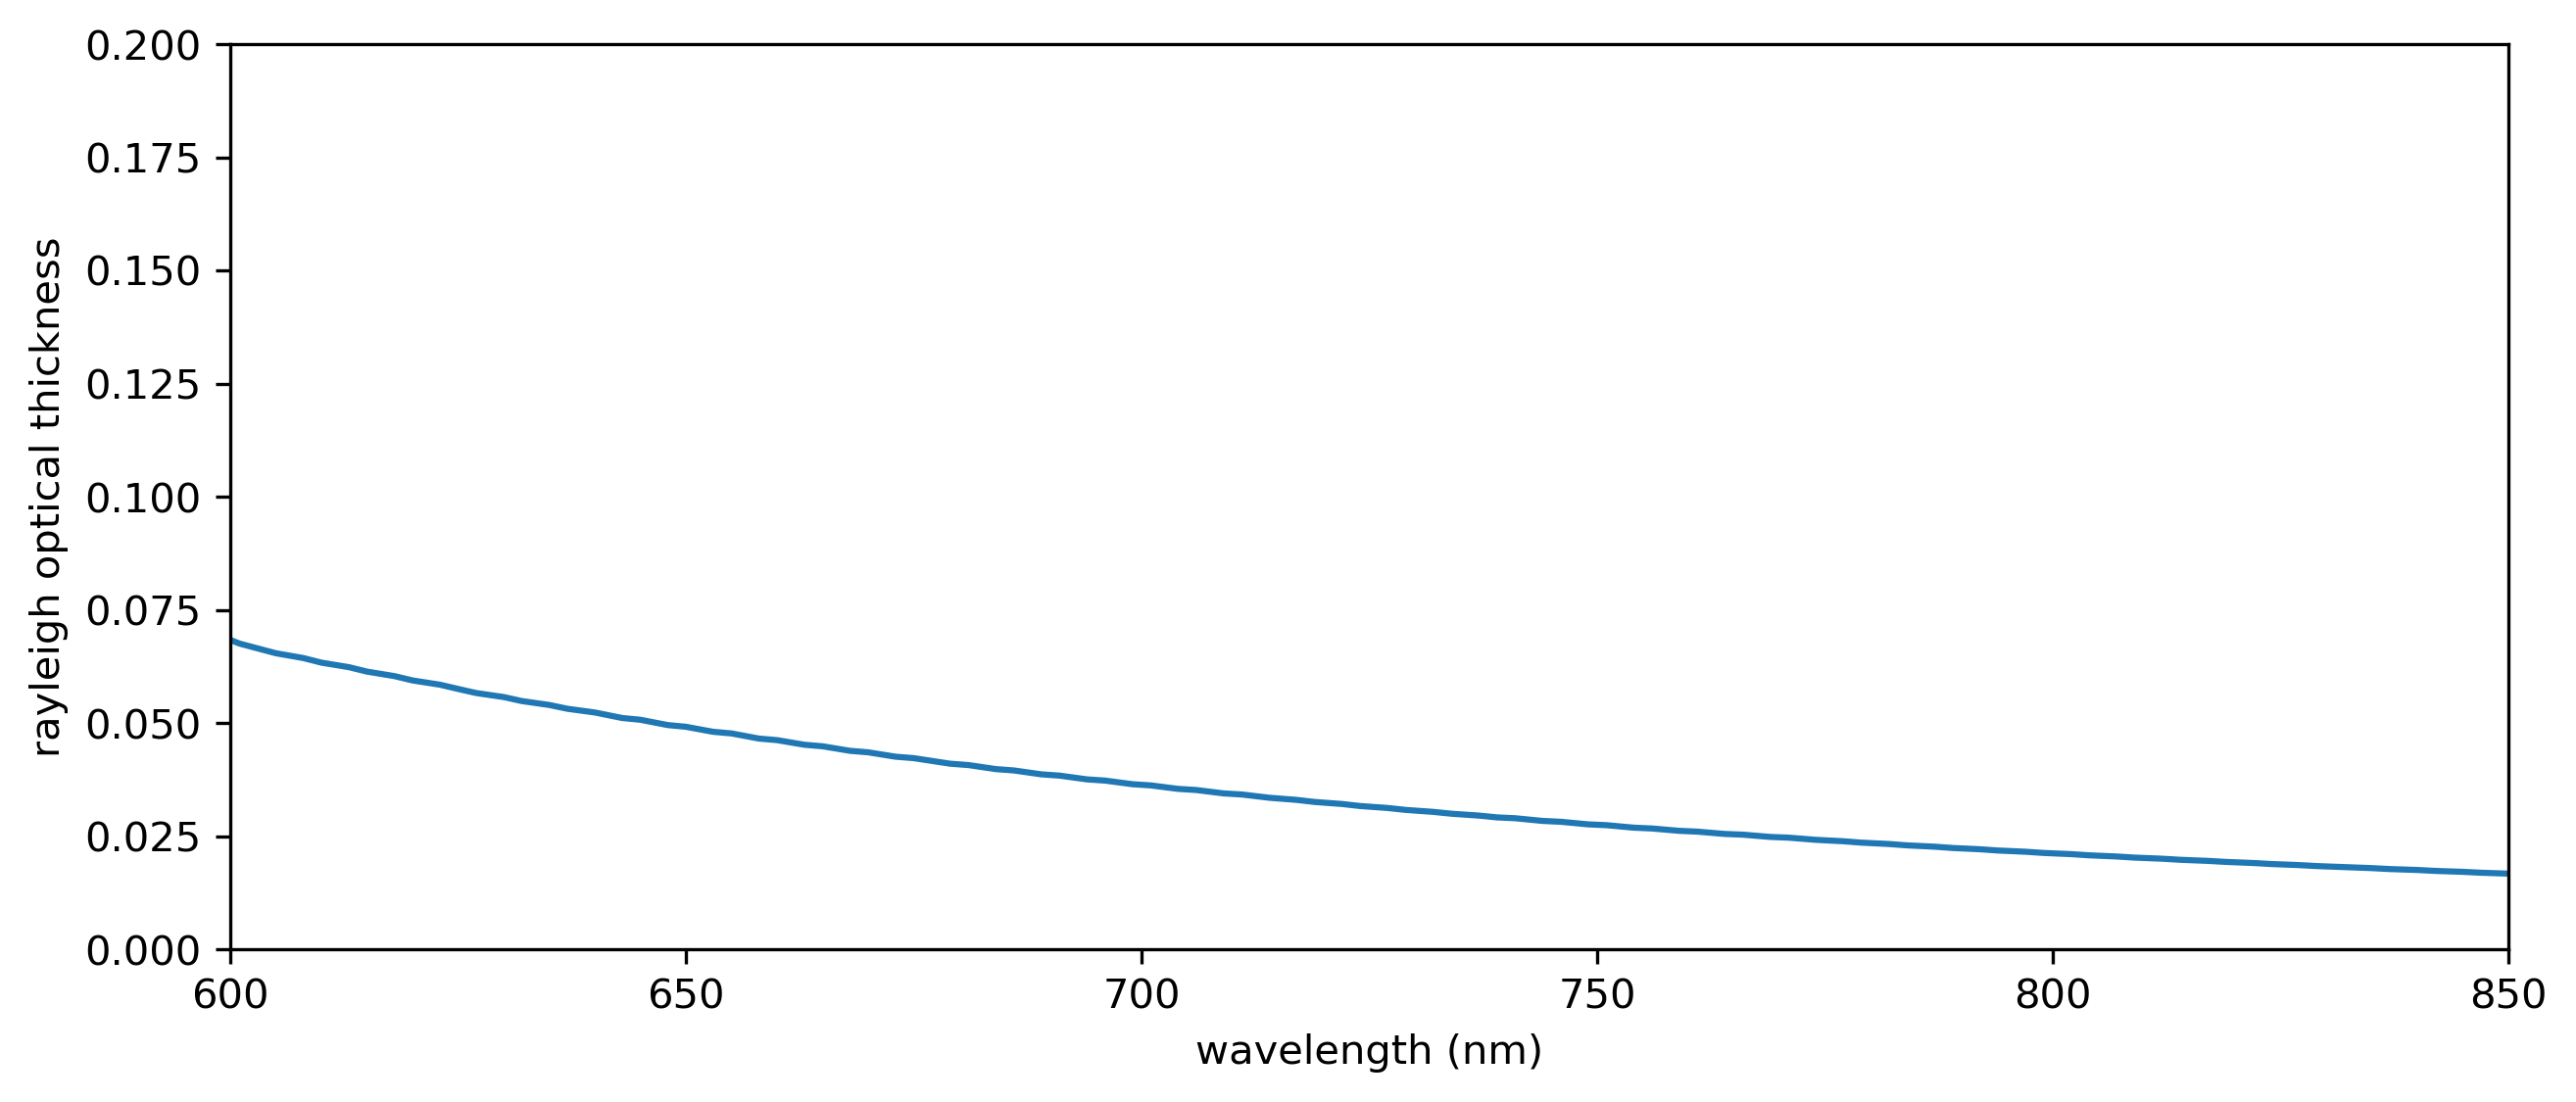

In [17]:
# rayleigh optical thickness
wavelength = ds_aop['wavelength'].values
rayleigh_optical_thickness = ds_aop['Tau_r'].values

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)
ax.plot(wavelength, rayleigh_optical_thickness)
ax.set_xlabel('wavelength (nm)')
ax.set_ylabel('rayleigh optical thickness')
ax.set_xlim(600, 850)
ax.set_ylim(0, 0.2)
plt.show()
